**Assignment-14**

**PCA**

In [1]:
import numpy as np
import pandas as pd


In [2]:
df=pd.read_csv('/content/wine.csv')

In [3]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [4]:
df.shape

(178, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

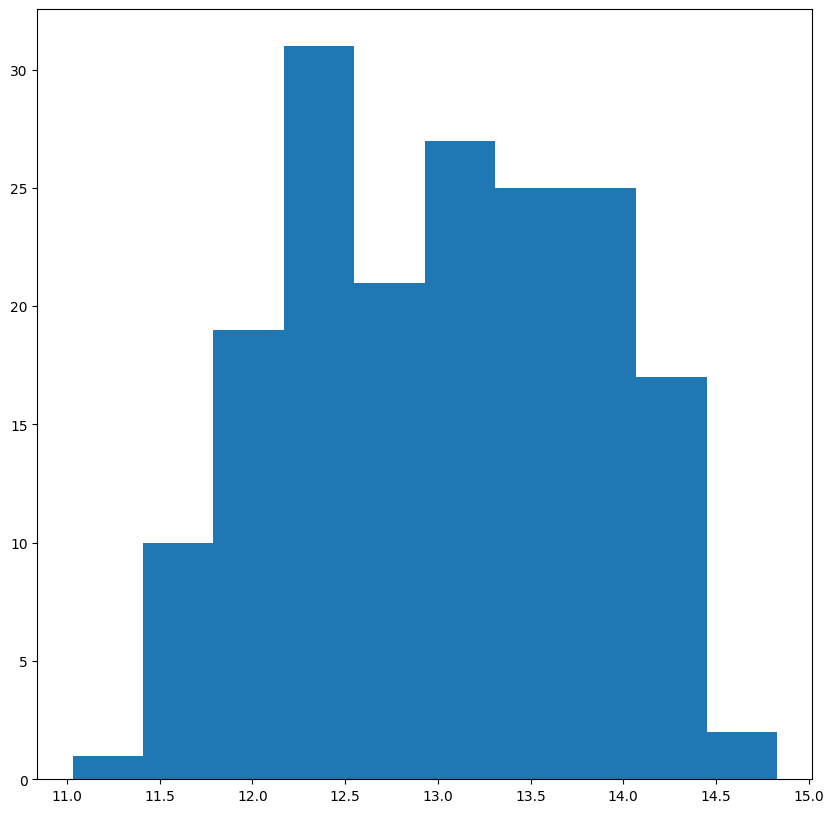

In [11]:
plt.figure(figsize=(10,10))
plt.hist(df['Alcohol'])
plt.show()

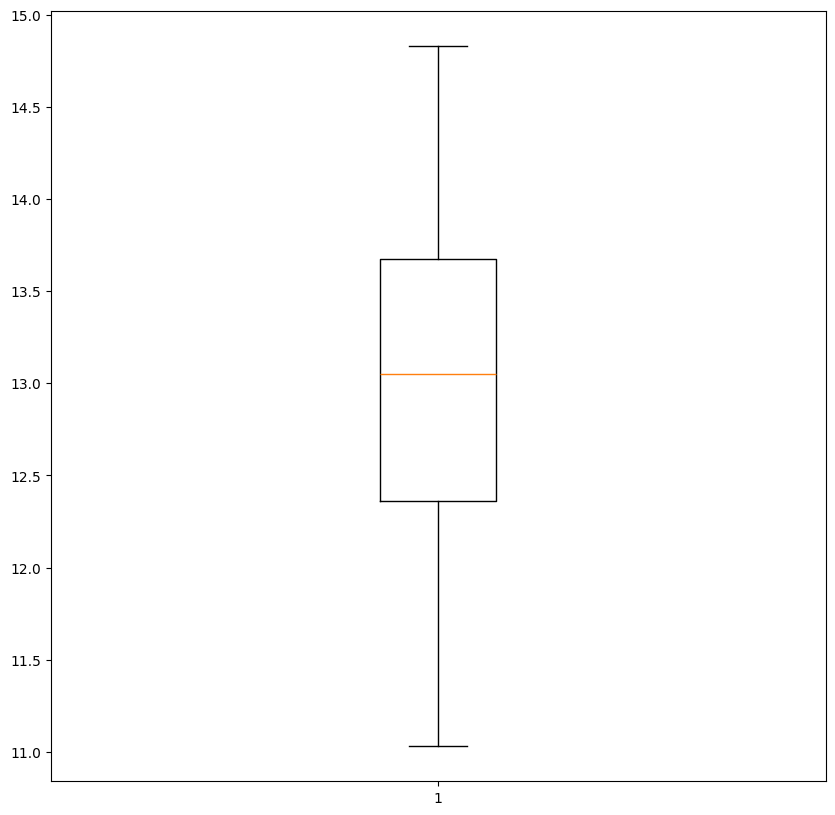

In [15]:
plt.figure(figsize=(10,10))
plt.boxplot(df['Alcohol'])
plt.show()

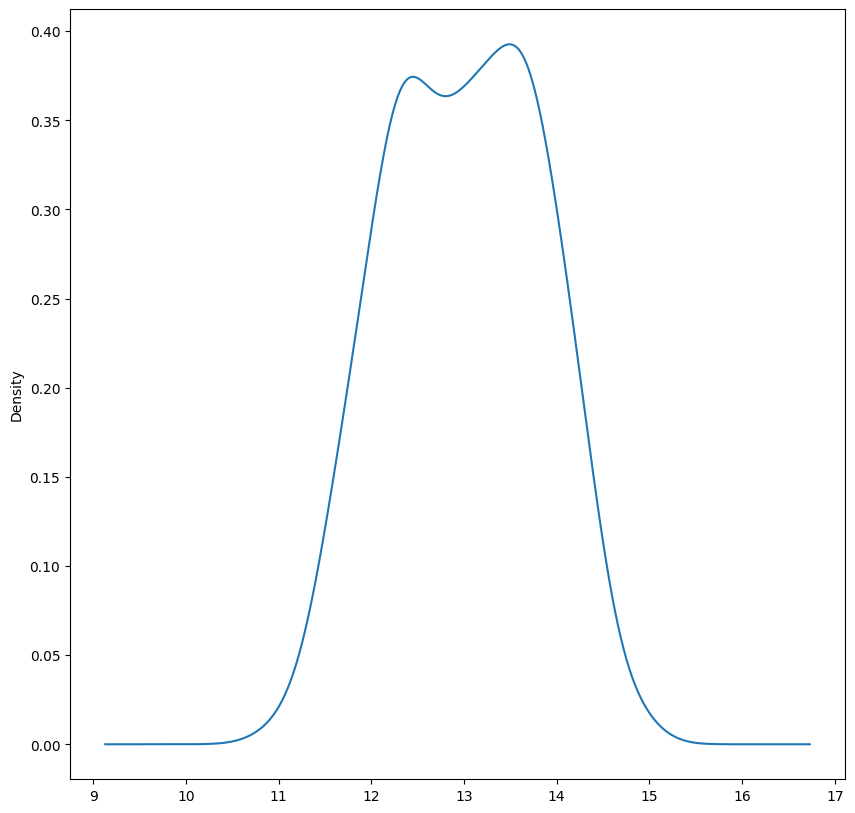

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
df['Alcohol'].plot.density()
plt.show()

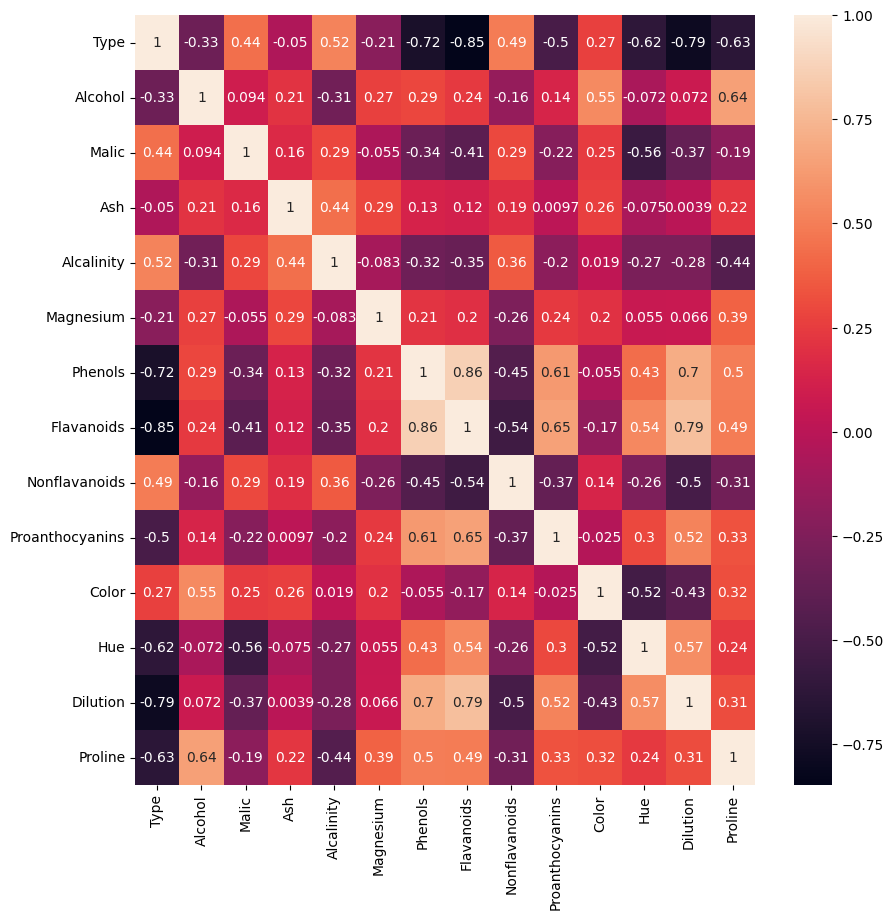

In [21]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(),annot=True)
plt.show()


In [24]:
from sklearn.preprocessing import StandardScaler

SS = StandardScaler()
X_scaled = SS.fit_transform(df.iloc[:,1:])

In [25]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca =pca.fit_transform(X_scaled)

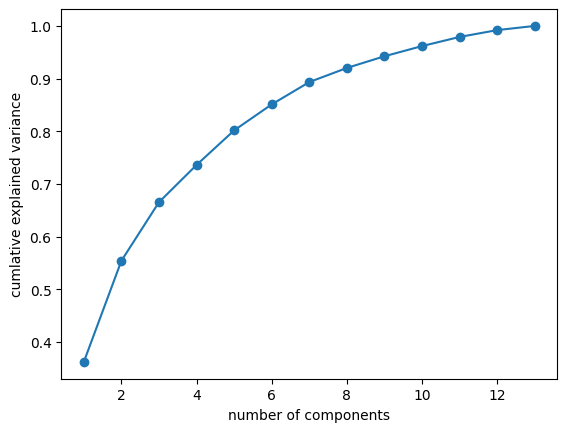

In [31]:
import matplotlib.pyplot as plt

cumlative_variance =np.cumsum(pca.explained_variance_ratio_)
plt.plot(range(1,len(cumlative_variance)+1),cumlative_variance,marker='o')
plt.xlabel('number of components')
plt.ylabel('cumlative explained variance')
plt.show()

In [33]:
print(cumlative_variance)

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


In [37]:
X= df.iloc[:,1:]
X_scaled=SS.fit_transform(X)
X_pca =pca.fit_transform(X_scaled)

In [38]:
X_pca

array([[ 3.31675081e+00,  1.44346263e+00, -1.65739045e-01, ...,
        -4.51563395e-01,  5.40810414e-01, -6.62386309e-02],
       [ 2.20946492e+00, -3.33392887e-01, -2.02645737e+00, ...,
        -1.42657306e-01,  3.88237741e-01,  3.63650247e-03],
       [ 2.51674015e+00,  1.03115130e+00,  9.82818670e-01, ...,
        -2.86672847e-01,  5.83573183e-04,  2.17165104e-02],
       ...,
       [-2.67783946e+00,  2.76089913e+00, -9.40941877e-01, ...,
         5.12492025e-01,  6.98766451e-01,  7.20776948e-02],
       [-2.38701709e+00,  2.29734668e+00, -5.50696197e-01, ...,
         2.99821968e-01,  3.39820654e-01, -2.18657605e-02],
       [-3.20875816e+00,  2.76891957e+00,  1.01391366e+00, ...,
        -2.29964331e-01, -1.88787963e-01, -3.23964720e-01]])

In [44]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X)

df['Cluster'] = clusters


In [45]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [47]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)
df['Cluster_PCA'] = clusters_pca

In [51]:
from sklearn.metrics import silhouette_score

silhouette_kmeans = silhouette_score(X_scaled, clusters)
silhouette_kmeans_pca = silhouette_score(X_pca, clusters_pca)

print("Silhouette Score (K-Means):", silhouette_kmeans)
print("Silhouette Score (K-Means with PCA):", silhouette_kmeans_pca)

Silhouette Score (K-Means): 0.0706997114643122
Silhouette Score (K-Means with PCA): 0.5601697480957203


In [52]:
print("Original Data:", silhouette_kmeans)
print("PCA Data:", silhouette_kmeans_pca)

Original Data: 0.0706997114643122
PCA Data: 0.5601697480957203


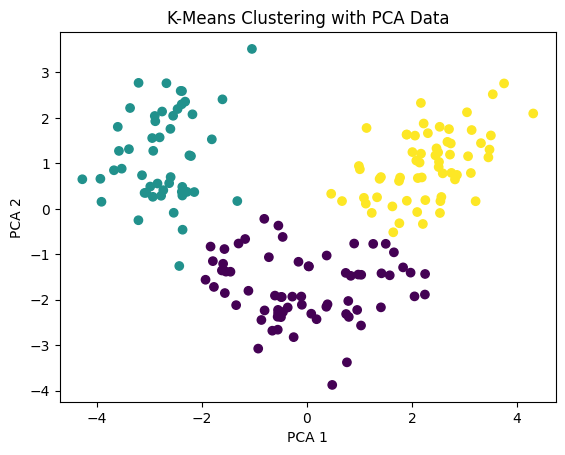

In [53]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca)

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering with PCA Data')

plt.show()

In [54]:
silhouette_kmeans
silhouette_kmeans_pca

np.float64(0.5601697480957203)

In [55]:
print("Original Data Silhouette Score:", silhouette_kmeans)
print("PCA Data Silhouette Score:", silhouette_kmeans_pca)

if silhouette_kmeans > silhouette_kmeans_pca:
    print("Original Data gives better clustering performance.")
elif silhouette_kmeans_pca > silhouette_kmeans:
    print("PCA Data gives better clustering performance.")
else:
    print("Both give the same clustering performance.")


Original Data Silhouette Score: 0.0706997114643122
PCA Data Silhouette Score: 0.5601697480957203
PCA Data gives better clustering performance.


Comparison: The clustering performed on PCA-transformed data produced a higher Silhouette Score (0.560) compared to the clustering performed on the original data (0.071). This indicates that the clusters obtained after PCA are much better separated and more compact. PCA reduced the dimensionality of the dataset and helped improve the clustering performance.

Trade-off: Using PCA reduces the number of features, which can make clustering easier, faster, and easier to visualize. However, PCA transforms the original features into principal components, so the original feature meaning becomes less directly interpretable.

PCA improved clustering performance: The Silhouette Score increased from 0.071 for the original data to 0.560 after PCA, indicating better-separated clusters.

PCA reduces dimensionality: PCA reduced the number of features while retaining the important information, making the data easier to visualize and cluster.

Recommendation: PCA can be useful before clustering when the dataset has many features or when dimensionality reduction improves cluster separation. However, clustering on the original data may be preferred when retaining the original feature interpretation is important.